# Visualising datasets

In [28]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from ase.neighborlist import NeighborList, natural_cutoffs

def _get_bond_graph(atoms):
    """Return a deterministic covalent-bond adjacency map."""
    cutoffs = natural_cutoffs(atoms, mult=1.2)
    neighbor_list = NeighborList(
        cutoffs,
        self_interaction=False,
        bothways=True,
        skin=0.0,
    )
    neighbor_list.update(atoms)
    adjacency = {atom_idx: set() for atom_idx in range(len(atoms))}
    for atom_idx in range(len(atoms)):
        neighbor_indices, _ = neighbor_list.get_neighbors(atom_idx)
        adjacency[atom_idx].update(int(idx) for idx in neighbor_indices)
    return adjacency

def _get_carbon_bonds(atoms, adjacency):
    """Return adjacent carbon-index pairs in stable atom-index order."""
    symbols = atoms.get_chemical_symbols()
    return sorted(
        {
            tuple(sorted((atom_idx, neighbor_idx)))
            for atom_idx, neighbor_indices in adjacency.items()
            if symbols[atom_idx] == "C"
            for neighbor_idx in neighbor_indices
            if symbols[neighbor_idx] == "C"
        }
    )

def get_bond_lengths(atoms):
    """Return all covalently bonded C-C distances in deterministic order.

    The carbon skeleton is inferred from covalent-radius neighbor cutoffs, so
    this supports ethene, propene, butene, and larger hydrocarbons without
    relying on fixed atom indices. Distances are returned in Angstrom.
    """
    adjacency = _get_bond_graph(atoms)
    carbon_bonds = _get_carbon_bonds(atoms, adjacency)
    if not carbon_bonds:
        raise ValueError("Need at least one covalently bonded pair of carbon atoms.")
    return [atoms.get_distance(*pair, mic=True) for pair in carbon_bonds]

def get_dihedral(atoms):
    """Return the torsion angle about the most substituted C-C bond.

    Candidate C-C bonds are ranked by the number of hydrogens attached to
    their endpoints. This selects the alkene bond in the ethene, propene, and
    butene datasets. For each side of that bond, a carbon substituent is
    preferred over other elements, giving H-C-C-H, C-C-C-H, and C-C-C-C
    torsions respectively for those three molecules.
    """
    symbols = atoms.get_chemical_symbols()
    adjacency = _get_bond_graph(atoms)
    carbon_bonds = _get_carbon_bonds(atoms, adjacency)
    if not carbon_bonds:
        raise ValueError("Need at least one covalently bonded pair of carbon atoms.")

    def attached_hydrogen_count(bond):
        first, second = bond
        return sum(
            symbols[neighbor] == "H"
            for endpoint, other in ((first, second), (second, first))
            for neighbor in adjacency[endpoint]
            if neighbor != other
        )

    central_first, central_second = min(
        carbon_bonds,
        key=lambda bond: (attached_hydrogen_count(bond), bond),
    )

    def choose_substituent(endpoint, other_endpoint):
        candidates = [
            neighbor
            for neighbor in adjacency[endpoint]
            if neighbor != other_endpoint
        ]
        if not candidates:
            raise ValueError(
                "Cannot define a dihedral because a central carbon has "
                "no substituent."
            )
        return min(
            candidates,
            key=lambda idx: (symbols[idx] != "C", idx),
        )

    outer_first = choose_substituent(central_first, central_second)
    outer_second = choose_substituent(central_second, central_first)
    angle = atoms.get_dihedral(
        outer_first,
        central_first,
        central_second,
        outer_second,
        mic=bool(np.any(atoms.pbc)),
    )
    # ASE reports dihedrals in [0, 360). Fold equivalent clockwise and
    # anticlockwise rotations into [0, 180] so values close to 360 remain
    # adjacent to values close to 0 in descriptor space and scatter plots.
    unsigned_angle = min(angle, 360.0 - angle)
    return [unsigned_angle]

def get_force_magnitudes(atoms_list, atom_index, force_key="REF_forces"):
    """Return force magnitudes for one atom across every geometry and state.

    ``atom_index`` selects an atom in each geometry. The result has shape
    (n_geometries, n_states), matching the energy-surface layout. Source
    forces must be stored as (n_atoms, n_states, 3) in either
    ``atoms.arrays`` or ``atoms.info``.
    """
    magnitudes = []
    for geometry_index, atoms in enumerate(atoms_list):
        if force_key in atoms.arrays:
            forces = np.asarray(atoms.arrays[force_key], dtype=float)
        elif force_key in atoms.info:
            forces = np.asarray(atoms.info[force_key], dtype=float)
        else:
            raise KeyError(
                f"Geometry {geometry_index} does not contain {force_key!r}."
            )
        if forces.ndim != 3 or forces.shape[0] != len(atoms) or forces.shape[-1] != 3:
            raise ValueError(
                f"Geometry {geometry_index} has {force_key} shape {forces.shape}; "
                "expected (n_atoms, n_states, 3)."
            )
        if not 0 <= atom_index < len(atoms):
            raise IndexError(
                f"atom_index {atom_index} is invalid for geometry {geometry_index} "
                f"with {len(atoms)} atoms."
            )
        magnitudes.append(np.linalg.norm(forces[atom_index], axis=-1))

    return np.stack(magnitudes)

In [38]:
XYZ = "../data/A01_ethene/static/A01_ethene_grid_static_CASSCF.xyz" # put path to data here
N_GEOMETRIES = 3731  # number of geometries to use from the dataset

atoms_list = ase.io.read(XYZ, index=f":{N_GEOMETRIES}")
print("Number of geometries:", len(atoms_list))

bond_lengths = []
dihedrals = []
energy_surfaces = None

bond_lengths = np.asarray([get_bond_lengths(atoms)[0] for atoms in atoms_list])
dihedrals = np.asarray([get_dihedral(atoms)[0] for atoms in atoms_list])
energies = np.vstack([np.asarray(atoms.info["REF_energy"]).ravel() for atoms in atoms_list])
energy_surfaces = [energies[:, state] for state in range(energies.shape[1])]
print("Number of energy surfaces:", len(energy_surfaces))

carbon_indices = [
    atom_index
    for atom_index, symbol in enumerate(atoms_list[0].get_chemical_symbols())
    if symbol == "C"
]
print("Carbon atom indices:", carbon_indices)

# One force-magnitude surface per carbon atom and electronic state.
force_magnitudes_by_carbon = {
    atom_index: get_force_magnitudes(atoms_list, atom_index)
    for atom_index in carbon_indices
}
for atom_index, force_magnitudes in force_magnitudes_by_carbon.items():
    if force_magnitudes.shape[1] != len(energy_surfaces):
        raise ValueError(
            f"Carbon atom {atom_index} has a different number of force and energy states."
        )

Number of geometries: 3731
Number of energy surfaces: 3
Carbon atom indices: [0, 1]


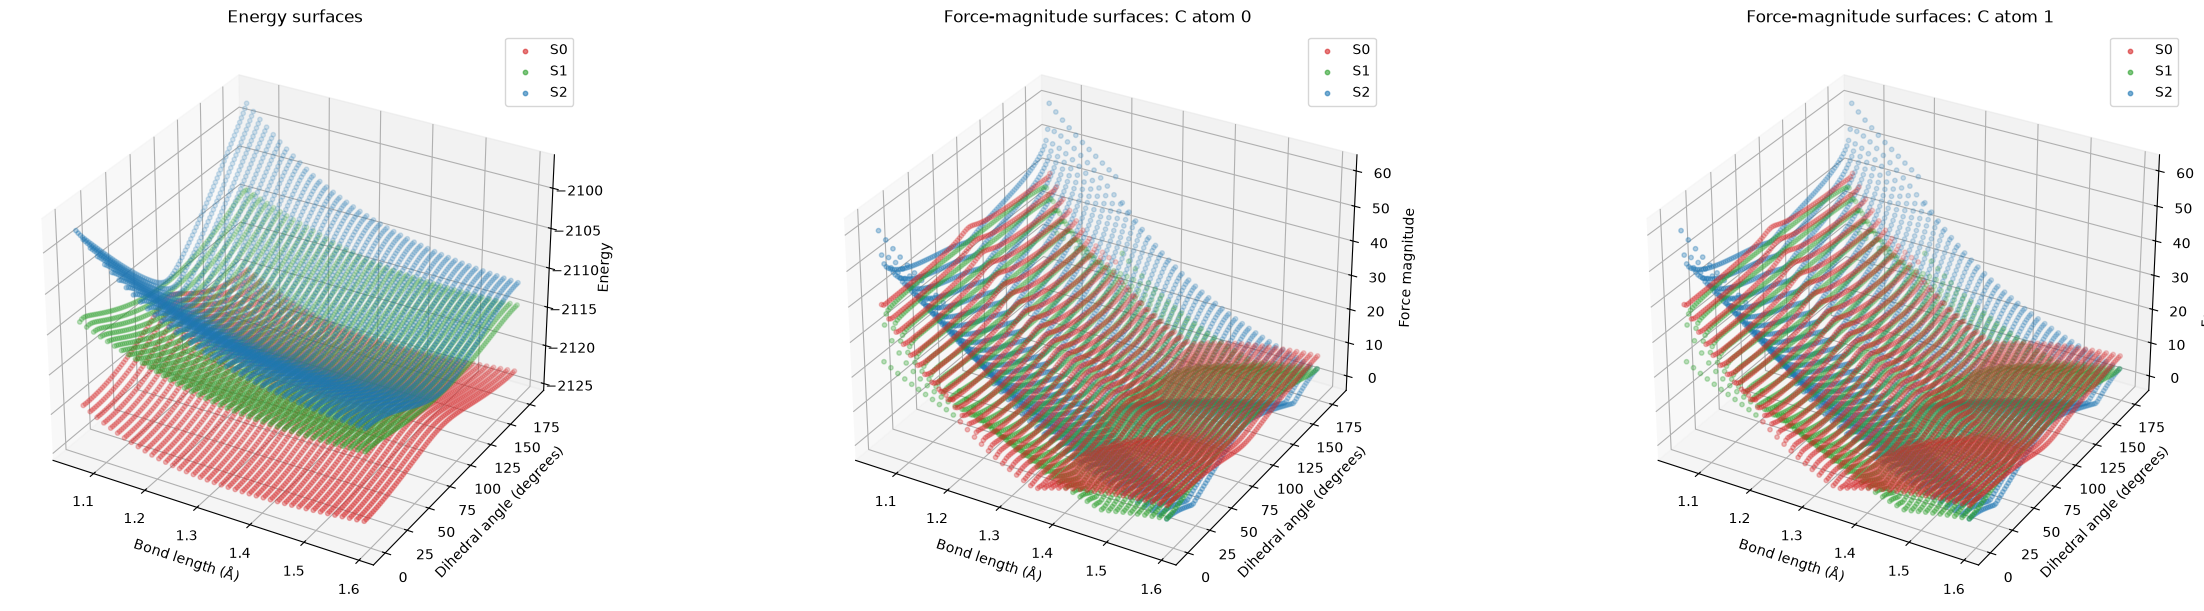

In [39]:
# Plot energy and per-carbon force surfaces in 3D.
%matplotlib inline

colors = ["tab:red", "tab:green", "tab:blue", "tab:purple"]
labels = [f"S{i}" for i in range(len(energy_surfaces))]

fig, axes = plt.subplots(
    1, 1 + len(carbon_indices), figsize=(8 * (1 + len(carbon_indices)), 6),
    subplot_kw={"projection": "3d"},
    constrained_layout=True,
)
for state, energy_surface in enumerate(energy_surfaces):
    plot_kwargs = dict(
        color=colors[state % len(colors)], s=10, alpha=0.6, label=labels[state]
    )
    axes[0].scatter(bond_lengths, dihedrals, energy_surface, **plot_kwargs)
    for column, atom_index in enumerate(carbon_indices, start=1):
        axes[column].scatter(
            bond_lengths,
            dihedrals,
            force_magnitudes_by_carbon[atom_index][:, state],
            **plot_kwargs,
        )

plot_titles = ["Energy surfaces"] + [
    f"Force-magnitude surfaces: C atom {atom_index}"
    for atom_index in carbon_indices
]
zlabels = ["Energy"] + ["Force magnitude"] * len(carbon_indices)
for ax, zlabel, title in zip(axes, zlabels, plot_titles):
    ax.set_xlabel("Bond length (Å)")
    ax.set_ylabel("Dihedral angle (degrees)")
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    ax.legend()
plt.show()


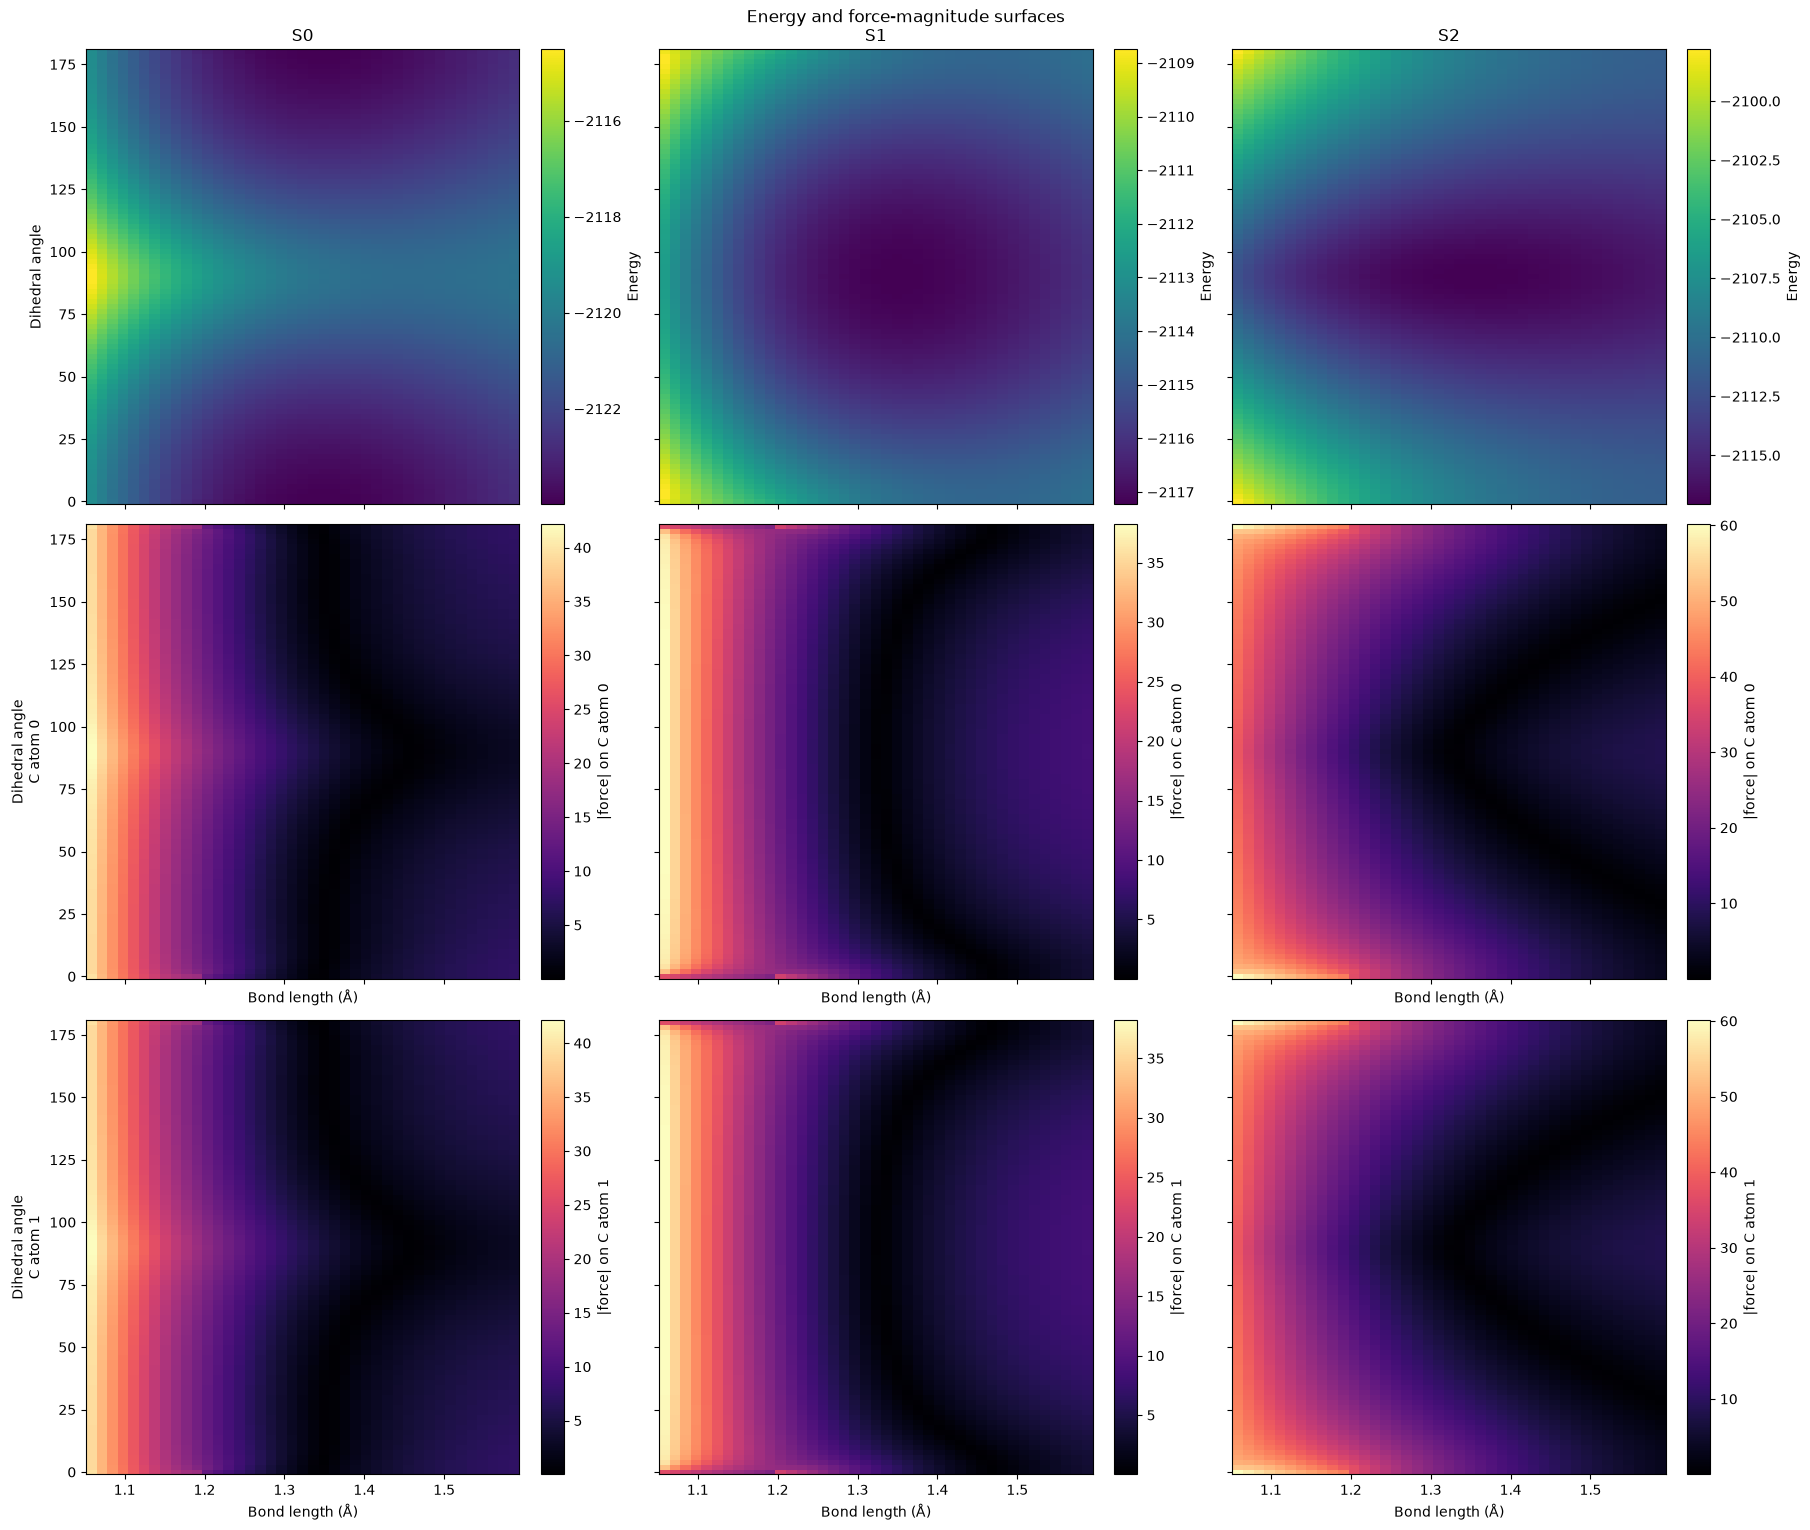

In [40]:
# plot heatmap
%matplotlib inline

bond_grid = np.unique(np.round(bond_lengths, 8))
dihedral_grid = np.unique(np.round(dihedrals, 8))
bond_idx = np.searchsorted(bond_grid, np.round(bond_lengths, 8))
dihedral_idx = np.searchsorted(dihedral_grid, np.round(dihedrals, 8))

fig, axes = plt.subplots(
    1 + len(carbon_indices), len(energy_surfaces),
    figsize=(6 * len(energy_surfaces), 5 * (1 + len(carbon_indices))),
    sharex=True, sharey=True, constrained_layout=True, squeeze=False,
)
for state, energy_surface in enumerate(energy_surfaces):
    energy_grid = np.full((len(dihedral_grid), len(bond_grid)), np.nan)
    energy_grid[dihedral_idx, bond_idx] = energy_surface
    energy_map = axes[0, state].pcolormesh(
        bond_grid, dihedral_grid, energy_grid, shading="nearest", cmap="viridis"
    )
    fig.colorbar(energy_map, ax=axes[0, state], label="Energy")
    axes[0, state].set_title(f"S{state}")

    for row, atom_index in enumerate(carbon_indices, start=1):
        force_grid = np.full((len(dihedral_grid), len(bond_grid)), np.nan)
        force_grid[dihedral_idx, bond_idx] = (
            force_magnitudes_by_carbon[atom_index][:, state]
        )
        force_map = axes[row, state].pcolormesh(
            bond_grid, dihedral_grid, force_grid, shading="nearest", cmap="magma"
        )
        fig.colorbar(
            force_map, ax=axes[row, state], label=f"|force| on C atom {atom_index}"
        )
        axes[row, state].set_xlabel("Bond length (Å)")

axes[0, 0].set_ylabel("Dihedral angle")
for row, atom_index in enumerate(carbon_indices, start=1):
    axes[row, 0].set_ylabel(f"Dihedral angle\nC atom {atom_index}")
fig.suptitle("Energy and force-magnitude surfaces", y=1.01)
plt.show()
